In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

discount = pd.read_csv(r"C:\Users\Admin\Downloads\archive (2)\Discount_Coupon.csv")
marketing = pd.read_csv(r"C:\Users\Admin\Downloads\archive (2)\Marketing_Spend.csv")
sales = pd.read_csv(r"C:\Users\Admin\Downloads\archive (2)\Online_Sales.csv")

In [5]:
discount.head()
marketing.head()
sales.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


In [6]:
discount.info()
marketing.info()
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Month             204 non-null    object
 1   Product_Category  204 non-null    object
 2   Coupon_Code       204 non-null    object
 3   Discount_pct      204 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           365 non-null    object 
 1   Offline_Spend  365 non-null    int64  
 2   Online_Spend   365 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 8.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------              

In [7]:
print(sales.isnull().sum())
print(marketing.isnull().sum())
print(discount.isnull().sum())
print(sales.duplicated().sum())

CustomerID             0
Transaction_ID         0
Transaction_Date       0
Product_SKU            0
Product_Description    0
Product_Category       0
Quantity               0
Avg_Price              0
Delivery_Charges       0
Coupon_Status          0
dtype: int64
Date             0
Offline_Spend    0
Online_Spend     0
dtype: int64
Month               0
Product_Category    0
Coupon_Code         0
Discount_pct        0
dtype: int64
0


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sales["Transaction_Date"] = pd.to_datetime(sales["Transaction_Date"])
marketing["Date"]         = pd.to_datetime(marketing["Date"])
sales["Revenue"]          = sales["Quantity"] * sales["Avg_Price"]
sales["Month"]            = sales["Transaction_Date"].dt.to_period("M")
sales["Month_Name"]       = sales["Transaction_Date"].dt.strftime("%b")
sales["Month_Num"]        = sales["Transaction_Date"].dt.month

first_tx             = sales.groupby("CustomerID")["Transaction_Date"].min().reset_index()
first_tx.columns     = ["CustomerID", "First_Purchase_Date"]
sales                = sales.merge(first_tx, on="CustomerID")
sales["Is_New"]      = sales["Transaction_Date"] == sales["First_Purchase_Date"]

sales.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Revenue,Month,Month_Name,Month_Num,First_Purchase_Date,Is_New
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,153.71,2019-01,Jan,1,2019-01-01,True
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,153.71,2019-01,Jan,1,2019-01-01,True
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,2.05,2019-01,Jan,1,2019-01-01,True
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,87.65,2019-01,Jan,1,2019-01-01,True
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,16.50,2019-01,Jan,1,2019-01-01,True


In [9]:
marketing["Month"]    = marketing["Date"].dt.to_period("M")
monthly_mkt           = marketing.groupby("Month")[["Offline_Spend","Online_Spend"]].sum()
monthly_mkt["Total_Marketing"] = monthly_mkt["Offline_Spend"] + monthly_mkt["Online_Spend"]

monthly_sales = sales.groupby("Month").agg(
    Revenue      = ("Revenue",        "sum"),
    Transactions = ("Transaction_ID", "nunique"),
    Customers    = ("CustomerID",     "nunique")
).reset_index()

monthly               = monthly_mkt.reset_index().merge(monthly_sales, on="Month", how="inner")
monthly["ROAS"]       = monthly["Revenue"] / monthly["Total_Marketing"]
monthly["Month_Label"]= monthly["Month"].dt.strftime("%b")

monthly[["Month_Label","Revenue","Total_Marketing","ROAS"]]

,Month_Label,Revenue,Total_Marketing,ROAS
0,Jan,403624.58,154928.95,2.605224
1,Feb,310819.80,137107.92,2.266972
2,Mar,349608.09,122250.09,2.859778
3,Apr,401618.42,157026.83,2.557642
4,May,307763.42,118259.64,2.602438
5,Jun,321081.38,134318.14,2.390454
6,Jul,372638.07,120217.85,3.099690
7,Aug,401210.37,142904.15,2.807549
8,Sep,360548.40,135514.54,2.660588
9,Oct,409681.28,151224.65,2.709091


In [10]:
total_tx      = len(sales)
clicked       = (sales["Coupon_Status"] == "Clicked").sum()
used          = (sales["Coupon_Status"] == "Used").sum()
not_used      = (sales["Coupon_Status"] == "Not Used").sum()
click_rate    = clicked  / total_tx * 100
use_rate      = used     / total_tx * 100
click_to_use  = used / (clicked + used) * 100

print(f"Total Transactions : {total_tx:,}")
print(f"Coupon Clicked     : {clicked:,}  ({click_rate:.1f}%)")
print(f"Coupon Used        : {used:,}  ({use_rate:.1f}%)")
print(f"Coupon Not Used    : {not_used:,}  ({(not_used/total_tx*100):.1f}%)")
print(f"Click-to-Use Rate  : {click_to_use:.1f}%")

Total Transactions : 52,924
Coupon Clicked     : 26,926  (50.9%)
Coupon Used        : 17,904  (33.8%)
Coupon Not Used    : 8,094  (15.3%)
Click-to-Use Rate  : 39.9%


In [11]:
cat_perf = sales.groupby("Product_Category").agg(
    Revenue      = ("Revenue",        "sum"),
    Transactions = ("Transaction_ID", "nunique"),
    Customers    = ("CustomerID",     "nunique"),
    Avg_Order    = ("Revenue",        "mean")
).sort_values("Revenue", ascending=False).reset_index()

cat_perf

,Product_Category,Revenue,Transactions,Customers,Avg_Order
0,Nest-USA,2554202.39,11626,1260,182.273774
1,Apparel,591145.80,8129,1323,32.613141
2,Nest,518193.50,1974,516,235.756824
3,Office,276794.40,3526,1103,42.498756
4,Drinkware,200707.83,2524,919,57.624987
5,Bags,151314.43,1545,728,80.400866
6,Notebooks & Journals,107085.96,620,383,142.971909
7,Lifestyle,74385.70,1712,817,24.057471
8,Nest-Canada,70910.40,258,205,223.692114
9,Headgear,53471.44,674,425,69.353359


In [12]:
customers = pd.read_excel(r"C:\Users\Admin\Downloads\archive (2)\CustomersData.xlsx")

customers["Tenure_Bin"] = pd.cut(customers["Tenure_Months"],
    bins=[0,6,12,24,200], labels=["0-6 mo","6-12 mo","12-24 mo","24+ mo"])

tenure_dist   = customers["Tenure_Bin"].value_counts().sort_index()
location_dist = customers["Location"].value_counts()
new_ret       = sales.groupby("Is_New")["Revenue"].sum()
new_ret.index = ["Returning","New"]
loc_rev       = (sales.merge(customers[["CustomerID","Location"]], on="CustomerID")
                      .groupby("Location")["Revenue"].sum()
                      .sort_values(ascending=True))

print(tenure_dist)
print(new_ret)

Tenure_Bin
0-6 mo      153
6-12 mo     174
12-24 mo    361
24+ mo      780
Name: count, dtype: int64
Returning    2456815.28
New          2213979.34
Name: Revenue, dtype: float64


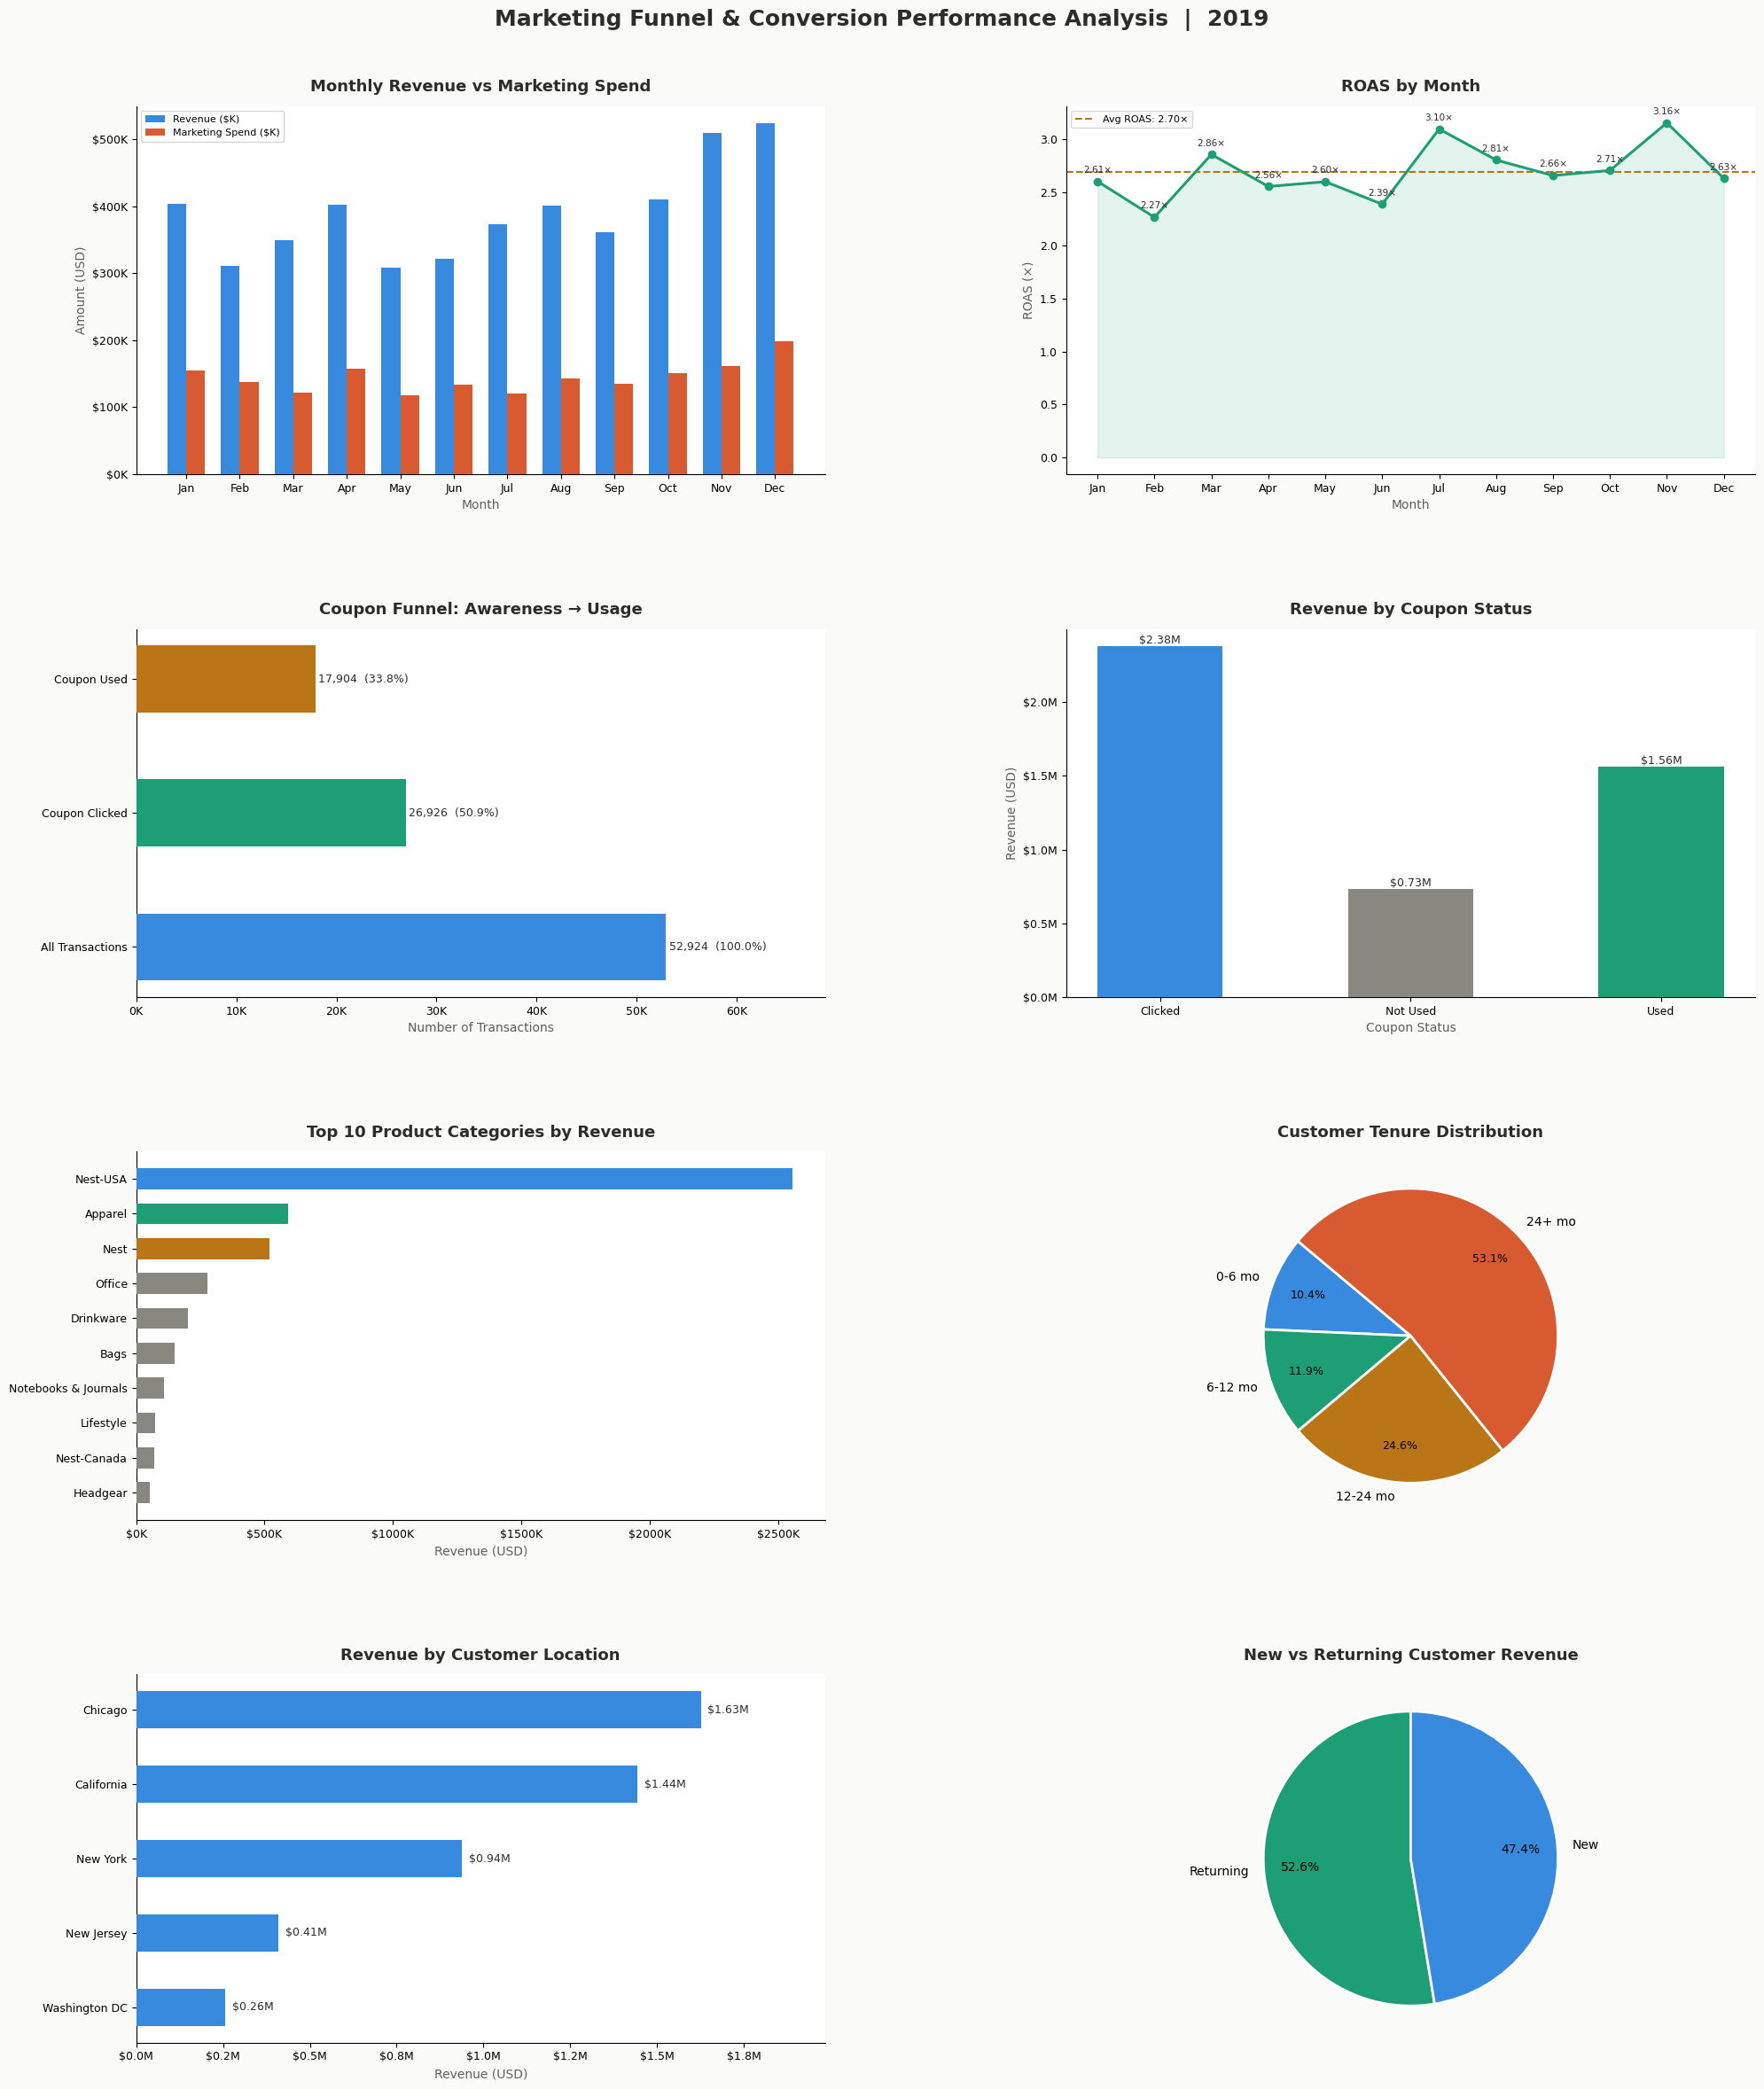

In [13]:
BLUE="#378ADD"; GREEN="#1D9E75"; AMBER="#BA7517"; CORAL="#D85A30"; GRAY="#888780"; DARK="#2C2C2A"
fig = plt.figure(figsize=(20,24))
fig.patch.set_facecolor("#FAFAF9")
fig.suptitle("Marketing Funnel & Conversion Performance Analysis  |  2019",
             fontsize=18, fontweight="bold", color=DARK, y=0.98)
tkw = dict(fontsize=13, fontweight="bold", color=DARK, pad=12)
lkw = dict(fontsize=10, color="#5F5E5A")
ml  = monthly["Month_Label"].tolist()
x   = np.arange(len(ml))

ax1 = fig.add_subplot(4,2,1); w=0.35
ax1.bar(x-w/2, monthly["Revenue"]/1000, width=w, color=BLUE, label="Revenue ($K)", zorder=3)
ax1.bar(x+w/2, monthly["Total_Marketing"]/1000, width=w, color=CORAL, label="Marketing Spend ($K)", zorder=3)
ax1.set_title("Monthly Revenue vs Marketing Spend", **tkw)
ax1.set_xticks(x); ax1.set_xticklabels(ml, fontsize=9); ax1.tick_params(axis="y", labelsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.0f}K"))
ax1.set_facecolor("white"); ax1.legend(fontsize=8)
ax1.set_xlabel("Month", **lkw); ax1.set_ylabel("Amount (USD)", **lkw)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

ax2 = fig.add_subplot(4,2,2)
ax2.plot(ml, monthly["ROAS"], color=GREEN, marker="o", linewidth=2.2, markersize=6, zorder=3)
ax2.fill_between(ml, monthly["ROAS"], alpha=0.12, color=GREEN)
ax2.axhline(monthly["ROAS"].mean(), color=AMBER, linewidth=1.5, linestyle="--",
            label=f"Avg ROAS: {monthly['ROAS'].mean():.2f}×")
ax2.set_title("ROAS by Month", **tkw); ax2.tick_params(labelsize=9)
ax2.set_facecolor("white"); ax2.legend(fontsize=8)
ax2.set_xlabel("Month", **lkw); ax2.set_ylabel("ROAS (×)", **lkw)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
for i,v in enumerate(monthly["ROAS"]):
    ax2.annotate(f"{v:.2f}×", (ml[i],v), textcoords="offset points",
                 xytext=(0,7), fontsize=7.5, ha="center", color=DARK)

ax3 = fig.add_subplot(4,2,3)
bh = ax3.barh(["All Transactions","Coupon Clicked","Coupon Used"],
              [total_tx, clicked, used], color=[BLUE,GREEN,AMBER], height=0.5, zorder=3)
ax3.set_title("Coupon Funnel: Awareness → Usage", **tkw)
ax3.set_facecolor("white"); ax3.tick_params(labelsize=9)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v/1000:.0f}K"))
ax3.set_xlabel("Number of Transactions", **lkw)
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
for bar,val,pct in zip(bh,[total_tx,clicked,used],[100.0,click_rate,use_rate]):
    ax3.text(bar.get_width()+300, bar.get_y()+bar.get_height()/2,
             f"{val:,}  ({pct:.1f}%)", va="center", fontsize=9, color=DARK)
ax3.set_xlim(0, total_tx*1.3)

ax4 = fig.add_subplot(4,2,4)
coupon_rev = sales.groupby("Coupon_Status")["Revenue"].sum().reset_index()
cmap = {"Clicked":BLUE,"Not Used":GRAY,"Used":GREEN}
b4 = ax4.bar(coupon_rev["Coupon_Status"], coupon_rev["Revenue"]/1e6,
             color=[cmap.get(s,GRAY) for s in coupon_rev["Coupon_Status"]], width=0.5, zorder=3)
ax4.set_title("Revenue by Coupon Status", **tkw); ax4.set_facecolor("white"); ax4.tick_params(labelsize=9)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.1f}M"))
ax4.set_xlabel("Coupon Status", **lkw); ax4.set_ylabel("Revenue (USD)", **lkw)
ax4.spines["top"].set_visible(False); ax4.spines["right"].set_visible(False)
for bar in b4:
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f"${bar.get_height():.2f}M", ha="center", fontsize=9, color=DARK)

ax5 = fig.add_subplot(4,2,5); top10 = cat_perf.head(10)
cc = [BLUE if i==0 else GREEN if i==1 else AMBER if i==2 else GRAY for i in range(len(top10))]
ax5.barh(top10["Product_Category"][::-1], top10["Revenue"][::-1]/1000,
         color=cc[::-1], height=0.6, zorder=3)
ax5.set_title("Top 10 Product Categories by Revenue", **tkw)
ax5.set_facecolor("white"); ax5.tick_params(labelsize=9)
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.0f}K"))
ax5.set_xlabel("Revenue (USD)", **lkw)
ax5.spines["top"].set_visible(False); ax5.spines["right"].set_visible(False)

ax6 = fig.add_subplot(4,2,6)
_,_,autos6 = ax6.pie(tenure_dist.values, labels=tenure_dist.index,
    colors=[BLUE,GREEN,AMBER,CORAL], autopct="%1.1f%%", startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2))
for at in autos6: at.set_fontsize(9)
ax6.set_title("Customer Tenure Distribution", **tkw)

ax7 = fig.add_subplot(4,2,7)
ax7.barh(loc_rev.index, loc_rev.values/1e6, color=BLUE, height=0.5, zorder=3)
ax7.set_title("Revenue by Customer Location", **tkw)
ax7.set_facecolor("white"); ax7.tick_params(labelsize=9)
ax7.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.1f}M"))
ax7.set_xlabel("Revenue (USD)", **lkw)
ax7.spines["top"].set_visible(False); ax7.spines["right"].set_visible(False)
for i,(loc,val) in enumerate(zip(loc_rev.index, loc_rev.values)):
    ax7.text(val/1e6+0.02, i, f"${val/1e6:.2f}M", va="center", fontsize=9, color=DARK)
ax7.set_xlim(0, loc_rev.max()/1e6*1.22)

ax8 = fig.add_subplot(4,2,8)
_,_,autos8 = ax8.pie(new_ret.values/1e6, labels=new_ret.index,
    colors=[GREEN,BLUE], autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2))
for at in autos8: at.set_fontsize(10)
ax8.set_title("New vs Returning Customer Revenue", **tkw)

plt.tight_layout(rect=[0,0,1,0.97])
plt.subplots_adjust(hspace=0.42, wspace=0.35)
plt.savefig("marketing_funnel_report.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

In [14]:
total_revenue   = sales["Revenue"].sum()
total_mkt_spend = monthly["Total_Marketing"].sum()
avg_roas        = total_revenue / total_mkt_spend
returning_rev   = new_ret["Returning"]
new_rev         = new_ret["New"]

print("=" * 55)
print(f"  Total Revenue         : ${total_revenue:>12,.2f}")
print(f"  Total Marketing Spend : ${total_mkt_spend:>12,.2f}")
print(f"  Average ROAS          : {avg_roas:>12.2f}x")
print(f"  Unique Customers      : {sales['CustomerID'].nunique():>12,}")
print(f"  Total Transactions    : {sales['Transaction_ID'].nunique():>12,}")
print(f"  Coupon Click Rate     : {click_rate:>11.1f}%")
print(f"  Coupon Use Rate       : {use_rate:>11.1f}%")
print(f"  Click-to-Use Rate     : {click_to_use:>11.1f}%")
print(f"  Returning Revenue %   : {returning_rev/(returning_rev+new_rev)*100:>11.1f}%")
print("=" * 55)

  Total Revenue         : $4,670,794.62
  Total Marketing Spend : $1,733,546.47
  Average ROAS          :         2.69x
  Unique Customers      :        1,468
  Total Transactions    :       25,061
  Coupon Click Rate     :        50.9%
  Coupon Use Rate       :        33.8%
  Click-to-Use Rate     :        39.9%
  Returning Revenue %   :        52.6%


In [15]:
recommendations = {
    "Fix Coupon Drop-off"       : f"{click_rate:.0f}% clicked but only {use_rate:.0f}% used. Auto-apply coupons at checkout.",
    "Scale Q4 Budget"           : "Nov ROAS peaked at 3.16x. Shift 10-15% of mid-year budget to Oct-Dec.",
    "Protect Nest-USA Margins"  : f"Nest-USA = {cat_perf.iloc[0]['Revenue']/total_revenue*100:.0f}% of revenue. Avoid deep discounts.",
    "Build Loyalty Programme"   : "53% revenue from returning customers. Reward 24mo+ tier to increase LTV."
}

pd.DataFrame(recommendations.items(), columns=["Recommendation", "Action"])

,Recommendation,Action
0,Fix Coupon Drop-off,51% clicked but only 34% used. Auto-apply coup...
1,Scale Q4 Budget,Nov ROAS peaked at 3.16x. Shift 10-15% of mid-...
2,Protect Nest-USA Margins,Nest-USA = 55% of revenue. Avoid deep discounts.
3,Build Loyalty Programme,53% revenue from returning customers. Reward 2...


In [16]:
pd.set_option("display.max_colwidth", None)

recommendations = {
    "Fix Coupon Drop-off"      : f"{click_rate:.0f}% clicked but only {use_rate:.0f}% used. Auto-apply coupons at checkout.",
    "Scale Q4 Budget"          : "Nov ROAS peaked at 3.16x. Shift 10-15% of mid-year budget to Oct-Dec.",
    "Protect Nest-USA Margins" : f"Nest-USA = {cat_perf.iloc[0]['Revenue']/total_revenue*100:.0f}% of revenue. Avoid deep discounts.",
    "Build Loyalty Programme"  : "53% revenue from returning customers. Reward 24mo+ tier to increase LTV."
}

pd.DataFrame(recommendations.items(), columns=["Recommendation", "Action"])

,Recommendation,Action
0,Fix Coupon Drop-off,51% clicked but only 34% used. Auto-apply coupons at checkout.
1,Scale Q4 Budget,Nov ROAS peaked at 3.16x. Shift 10-15% of mid-year budget to Oct-Dec.
2,Protect Nest-USA Margins,Nest-USA = 55% of revenue. Avoid deep discounts.
3,Build Loyalty Programme,53% revenue from returning customers. Reward 24mo+ tier to increase LTV.
